# 02 - Basket Option Pricing

This notebook prices a European basket call using the synthetic market data created in notebook 01.

It uses the saved outputs from `01_synthetic_stock_data_and_correlations.ipynb` rather than rebuilding the market setup from scratch.

Scope for this notebook:

- load the synthetic stock-path data and model inputs,
- price a European basket call under constant correlation,
- price the same option under regime-switching correlation,
- report Monte Carlo standard errors and confidence intervals,
- check convergence as the number of paths increases.

No hedging is included yet.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

In [2]:
base_dir = Path.cwd()
repo_root = base_dir.parent if base_dir.name == "notebooks" else base_dir
data_dir = repo_root / "data" / "synthetic"

required_files = [
    data_dir / "synthetic_market_data.npz",
    data_dir / "asset_parameters.csv",
    data_dir / "market_settings.csv",
]
missing = [path for path in required_files if not path.exists()]
if missing:
    missing_text = "\n".join(str(path) for path in missing)
    raise FileNotFoundError(
        "Notebook 01 must be executed before running this notebook. Missing files:\n"
        f"{missing_text}"
    )

bundle = np.load(data_dir / "synthetic_market_data.npz")
asset_parameters = pd.read_csv(data_dir / "asset_parameters.csv", index_col=0)
market_settings = pd.read_csv(data_dir / "market_settings.csv", index_col=0).iloc[:, 0]

asset_names = bundle["asset_names"].tolist()
spot = bundle["spot"]
weights = bundle["weights"]
vol = bundle["vol"]
div_yield = bundle["div_yield"]
rate = float(bundle["rate"])
maturity = float(bundle["maturity"])
steps = int(bundle["steps"])
n_paths = int(bundle["n_paths"])

constant_paths = bundle["constant_paths"]
switching_paths = bundle["switching_paths"]
switching_regimes = bundle["switching_regimes"]
corr_constant = bundle["corr_constant"]
corr_calm = bundle["corr_calm"]
corr_stress = bundle["corr_stress"]

initial_basket = float(weights @ spot)
strike = initial_basket

display(asset_parameters)
display(market_settings.to_frame(name="value"))
print(f"Initial basket level: {initial_basket:.4f}")
print(f"ATM strike used for pricing: {strike:.4f}")

,spot,weight,volatility,dividend_yield
Asset 1,100.0,0.40,0.20,0.0
Asset 2,95.0,0.35,0.25,0.0
Asset 3,110.0,0.25,0.22,0.0


,value
risk_free_rate,0.03
maturity_years,1.00
time_steps,252.00
monte_carlo_paths,3000.00
rho_constant,0.35
rho_calm,0.20
rho_stress,0.75
p01,0.03
p10,0.12


Initial basket level: 100.7500
ATM strike used for pricing: 100.7500


## Pricing Helpers

In [3]:
def basket_values(terminal_prices, weights):
    return terminal_prices @ weights


def basket_call_payoffs(terminal_prices, weights, strike):
    basket_terminal = basket_values(terminal_prices, weights)
    payoffs = np.maximum(basket_terminal - strike, 0.0)
    return basket_terminal, payoffs


def monte_carlo_price_summary(payoffs, rate, maturity, confidence_level=0.95):
    discounted_payoffs = np.exp(-rate * maturity) * payoffs
    n_obs = discounted_payoffs.size
    mean_price = discounted_payoffs.mean()
    std_dev = discounted_payoffs.std(ddof=1)
    std_error = std_dev / np.sqrt(n_obs)

    z_score = 1.96 if confidence_level == 0.95 else 1.96
    ci_low = mean_price - z_score * std_error
    ci_high = mean_price + z_score * std_error

    return pd.Series(
        {
            "price": mean_price,
            "std_error": std_error,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "discounted_payoff_std": std_dev,
            "n_paths": n_obs,
        }
    )


def convergence_table(payoffs, rate, maturity, path_counts):
    rows = []
    for count in path_counts:
        summary = monte_carlo_price_summary(payoffs[:count], rate, maturity)
        summary["n_paths"] = count
        rows.append(summary)

    return pd.DataFrame(rows).reset_index(drop=True)


In [4]:
constant_terminal = constant_paths[:, -1, :]
switching_terminal = switching_paths[:, -1, :]

basket_constant, payoffs_constant = basket_call_payoffs(constant_terminal, weights, strike)
basket_switching, payoffs_switching = basket_call_payoffs(switching_terminal, weights, strike)

pricing_summary = pd.DataFrame(
    {
        "Constant correlation": monte_carlo_price_summary(payoffs_constant, rate, maturity),
        "Regime switching": monte_carlo_price_summary(payoffs_switching, rate, maturity),
    }
).T

pricing_summary["price_difference_vs_constant"] = pricing_summary["price"] - pricing_summary.loc["Constant correlation", "price"]

stress_fraction = switching_regimes.mean()

display(pricing_summary.round(4))
print(f"Average fraction of time spent in the stress regime: {stress_fraction:.2%}")

,price,std_error,ci_low,ci_high,discounted_payoff_std,n_paths,price_difference_vs_constant
Constant correlation,8.3395,0.2203,7.9076,8.7713,12.0687,3000.0,0.0000
Regime switching,8.2780,0.2145,7.8575,8.6985,11.7511,3000.0,-0.0615


Average fraction of time spent in the stress regime: 19.51%


The regime-switching price differs from the constant-correlation price because the terminal basket distribution changes when the path can spend part of the year in a high-correlation stress state.

In [5]:
path_grid = np.array([100, 250, 500, 1000, 1500, 2000, 2500, 3000])

convergence_constant = convergence_table(payoffs_constant, rate, maturity, path_grid)
convergence_constant["model"] = "Constant correlation"

convergence_switching = convergence_table(payoffs_switching, rate, maturity, path_grid)
convergence_switching["model"] = "Regime switching"

convergence_results = pd.concat([convergence_constant, convergence_switching], ignore_index=True)

display(convergence_results.round(4))

,price,std_error,ci_low,ci_high,discounted_payoff_std,n_paths,model
0,7.6556,1.1856,5.3318,9.9793,11.8557,100.0,Constant correlation
1,9.0165,0.8196,7.4100,10.6229,12.9595,250.0,Constant correlation
2,8.9372,0.5772,7.8058,10.0686,12.9074,500.0,Constant correlation
3,8.2075,0.3778,7.4669,8.9480,11.9480,1000.0,Constant correlation
4,8.4504,0.3137,7.8357,9.0652,12.1476,1500.0,Constant correlation
5,8.4677,0.2722,7.9343,9.0012,12.1720,2000.0,Constant correlation
6,8.2267,0.2394,7.7576,8.6959,11.9682,2500.0,Constant correlation
7,8.3395,0.2203,7.9076,8.7713,12.0687,3000.0,Constant correlation
8,7.7147,1.1165,5.5264,9.9030,11.1649,100.0,Regime switching
9,7.9334,0.7045,6.5525,9.3143,11.1398,250.0,Regime switching


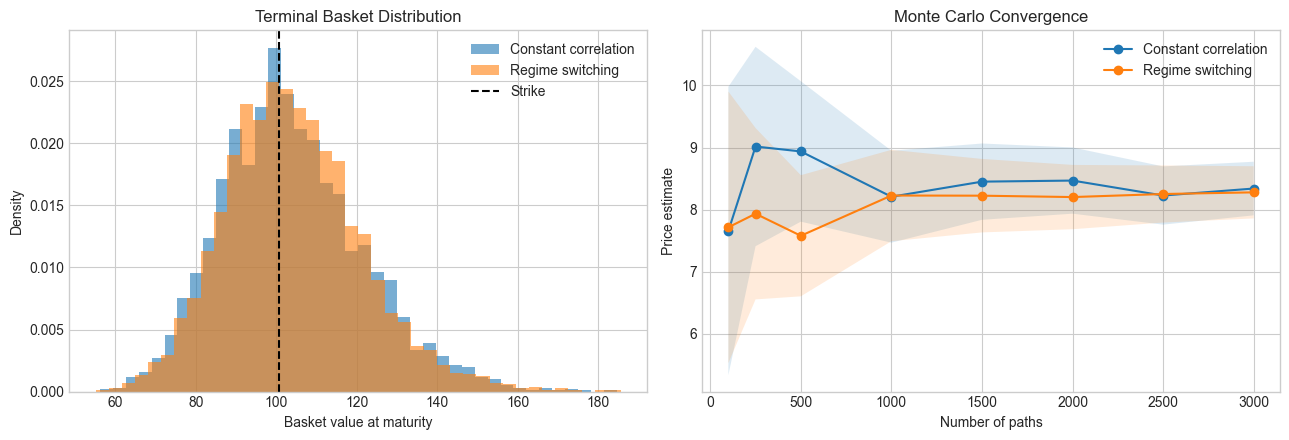

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(basket_constant, bins=40, alpha=0.6, label="Constant correlation", density=True)
axes[0].hist(basket_switching, bins=40, alpha=0.6, label="Regime switching", density=True)
axes[0].axvline(strike, color="black", linestyle="--", linewidth=1.5, label="Strike")
axes[0].set_title("Terminal Basket Distribution")
axes[0].set_xlabel("Basket value at maturity")
axes[0].set_ylabel("Density")
axes[0].legend()

for frame, label in [
    (convergence_constant, "Constant correlation"),
    (convergence_switching, "Regime switching"),
]:
    axes[1].plot(frame["n_paths"], frame["price"], marker="o", label=label)
    axes[1].fill_between(frame["n_paths"], frame["ci_low"], frame["ci_high"], alpha=0.15)

axes[1].set_title("Monte Carlo Convergence")
axes[1].set_xlabel("Number of paths")
axes[1].set_ylabel("Price estimate")
axes[1].legend()

plt.tight_layout()
plt.show()

## Persist Pricing Outputs

These tables will be useful in later notebooks when we compare pricing to hedging performance.

In [7]:
pricing_summary_to_save = pricing_summary.copy()
pricing_summary_to_save.index.name = "model"

pricing_summary_to_save.to_csv(data_dir / "basket_option_pricing_summary.csv")
convergence_results.to_csv(data_dir / "basket_option_pricing_convergence.csv", index=False)

print(f"Saved pricing summary to {data_dir / 'basket_option_pricing_summary.csv'}")
print(f"Saved convergence table to {data_dir / 'basket_option_pricing_convergence.csv'}")

Saved pricing summary to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_pricing_summary.csv
Saved convergence table to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_pricing_convergence.csv
